cargamos los datos y empezar a clasificar los datos para implementar las fórmulas de conversión que vienen en el README para que los datos no sean solo números crudos, sino valores con significado físico

este bloque ya incluye las fórmulas oficiales para transformar los bits en unidades reales (mV, µS, °C)

In [1]:
import pandas as pd
import pickle
import numpy as np

# Carga de datos
ruta_archivo = 'WESAD/S2/S2.pkl' # Ajusta según tu ruta
with open(ruta_archivo, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# Extraer señales del pecho (Chest)
fisiologicos = data['signal']['chest']
labels = data['label']

# --- APLICACIÓN DE FÓRMULAS DEL README ---
# Definimos constantes según el manual [cite: 31]
vcc = 3
chan_bit = 2**16

# 1. ECG en mV: ((signal/chan_bit - 0.5) * vcc) [cite: 32]
ecg_mv = ((fisiologicos['ECG'] / chan_bit) - 0.5) * vcc

# 2. EDA en µS: (((signal/chan_bit) * vcc) / 0.12) [cite: 33]
eda_us = ((fisiologicos['EDA'] / chan_bit) * vcc) / 0.12

# 3. TEMP en °C (Esta es la fórmula compleja del README) 
def convert_temp(signal):
    vout = (signal * vcc) / (chan_bit - 1)
    rntc = ((10**4) * vout) / (vcc - vout)
    # Ecuación Steinhart-Hart adaptada del manual
    temp_c = -273.15 + 1./(1.12764514e-03 + 2.34282709e-04 * np.log(rntc) + 8.77303013e-08 * (np.log(rntc)**3))
    return temp_c

# Creamos el DataFrame 
df = pd.DataFrame({
    'ECG': ecg_mv.flatten(),
    'EDA': eda_us.flatten(),
    'EMG': fisiologicos['EMG'].flatten(), 
    'TEMP': convert_temp(fisiologicos['Temp']).flatten(), 
    'RESP': fisiologicos['Resp'].flatten(),
    'Label': labels
})

# Filtrar solo las condiciones del estudio [cite: 63]
df = df[df['Label'].isin([1, 2, 3, 4])]
print("¡Datos cargados y convertidos con éxito!")

¡Datos cargados y convertidos con éxito!


Ya tenemos unidades fisicas reales, es decir, ya tenemos numeros que puede entender python y no solo el dispositivo de medicion de las pruebas
Para las magnitudes tan grandes que hay ejemplo la de 700hx con una de 10hz haremos 

Downsampling (Submuestreo): Vamos a reducir la frecuencia (por ejemplo, a 10 Hz o 1 Hz) calculando el promedio de esos puntos. Esto "suaviza" la señal y elimina picos de ruido electrónico.

Filtro de Mediana: Ideal para eliminar esos "outliers" repentinos que mencionaste sin deformar la tendencia de la señal.

tambien, notamos que al ponerle el dispositivo pro primera vez a un sujeto, e pone nervioso, y esto hace que sude, aunque claramente no todos sudan igual o se 
ponen nirviosos, para soluciuonar eso, usamos 

(Z-Score por sujeto)
En lugar de usar los valores reales, transformaremos cada señal para que nos diga: "¿Cuántas desviaciones estándar está este valor por encima o por debajo de la media de este sujeto?".

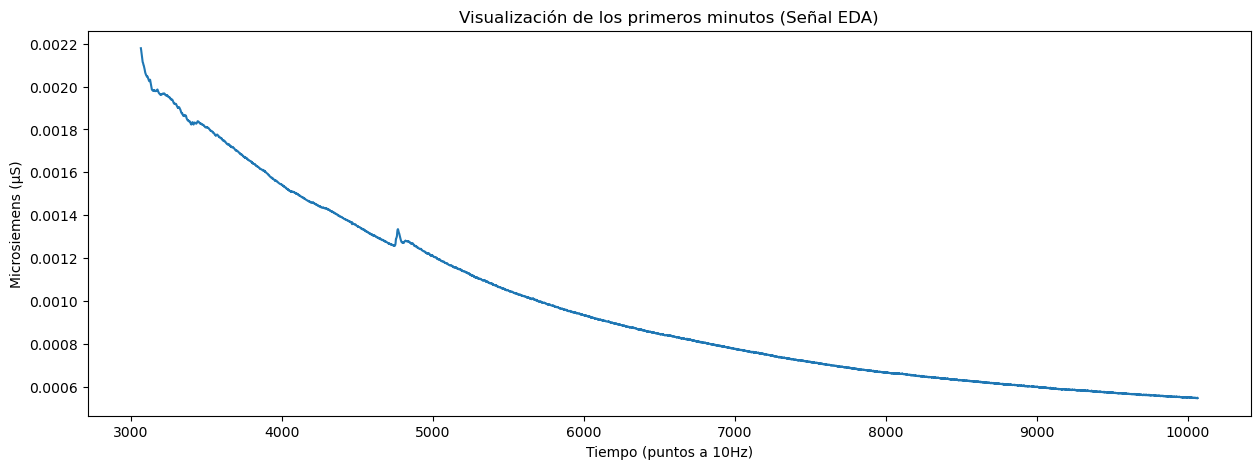

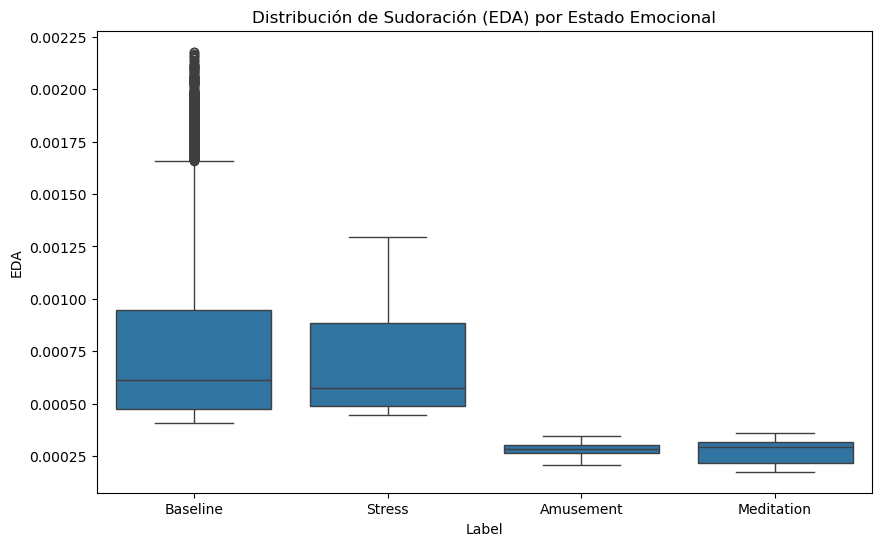

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Downsampling: Promediamos cada 70 registros (pasamos de 700Hz a 10Hz)
# Esto reduce el ruido y hace que el modelo sea más rápido
df_resampled = df.groupby(df.index // 70).mean()

# 2. Visualización para detectar Outliers y el "Efecto Nerviosismo"
plt.figure(figsize=(15, 5))
sns.lineplot(data=df_resampled.iloc[:7000], x=df_resampled.iloc[:7000].index, y='EDA')
plt.title("Visualización de los primeros minutos (Señal EDA)")
plt.ylabel("Microsiemens (µS)")
plt.xlabel("Tiempo (puntos a 10Hz)")
plt.show()

# 3. Comparación de Estados Emocionales (EDA por Etiqueta)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='EDA', data=df_resampled)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Baseline', 'Stress', 'Amusement', 'Meditation'])
plt.title("Distribución de Sudoración (EDA) por Estado Emocional")
plt.show()

como vemos, baseline tiene muchismos outliers arriba de 0.00175, esto se debe al nerviosismo inicial
lo que haremos sera cortar eso, sin embargo no es cortar por cortar, lo que hayq ue hacer es analizar y sacar un prmedio de 
cuanto dura, ya que no en todos los sujetos es igual

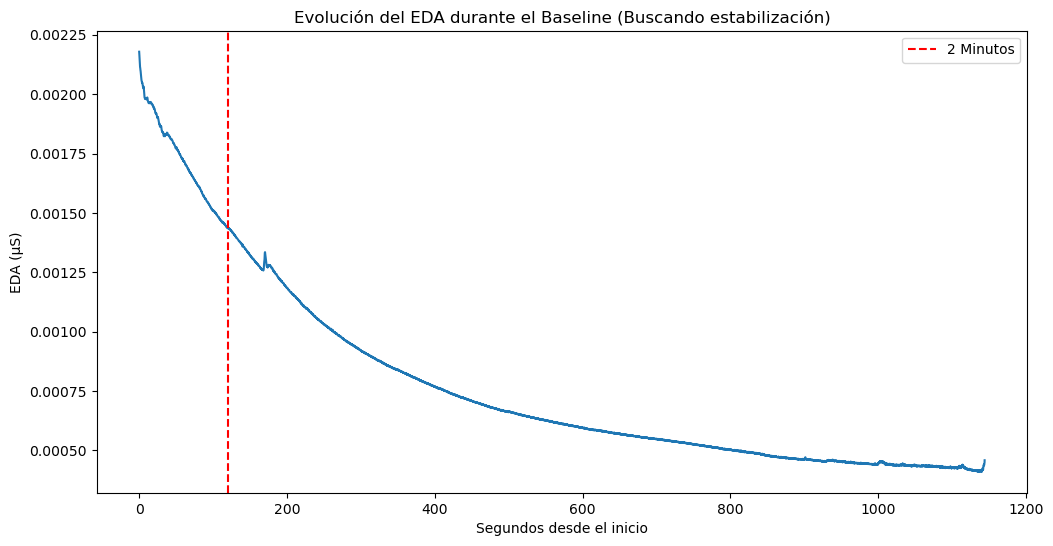

In [3]:
# Filtramos solo la etiqueta de Baseline (1)
df_baseline = df_resampled[df_resampled['Label'] == 1].copy()

# Creamos una columna de 'Segundos' para que sea más fácil de leer
# (Como hicimos downsampling a 10Hz, cada 10 puntos es 1 segundo)
df_baseline['segundos'] = np.arange(len(df_baseline)) / 10

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_baseline, x='segundos', y='EDA')
plt.axvline(x=120, color='red', linestyle='--', label='2 Minutos') # Marca de referencia
plt.title("Evolución del EDA durante el Baseline (Buscando estabilización)")
plt.xlabel("Segundos desde el inicio")
plt.ylabel("EDA (µS)")
plt.legend()
plt.show()

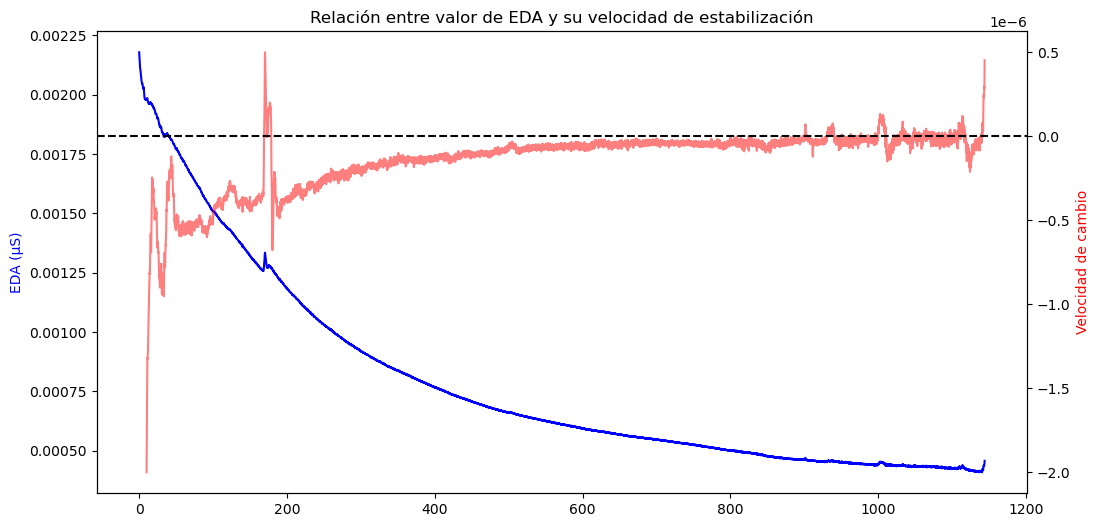

In [4]:
# Calculamos la pendiente (cambio) de la señal EDA
df_baseline['slope'] = df_baseline['EDA'].diff().rolling(window=100).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Graficamos la señal original
ax1.plot(df_baseline['segundos'], df_baseline['EDA'], color='blue', label='EDA Original')
ax1.set_ylabel('EDA (µS)', color='blue')

# Graficamos la pendiente en un segundo eje
ax2 = ax1.twinx()
ax2.plot(df_baseline['segundos'], df_baseline['slope'], color='red', alpha=0.5, label='Pendiente (Cambio)')
ax2.set_ylabel('Velocidad de cambio', color='red')
ax2.axhline(y=0, color='black', linestyle='--')

plt.title("Relación entre valor de EDA y su velocidad de estabilización")
plt.show()

comparamos mas o menos como es que se comporta la señal de origen (la roja) en comparacion a nuestra corte
como vemos no es perfecto, pero esto nos dio indicio a tomar en cuenta las otra svariables para ver si es que 
tenian algo que ver en esto para sacar el mejor tiempo en el cual cortar para no perder datos 

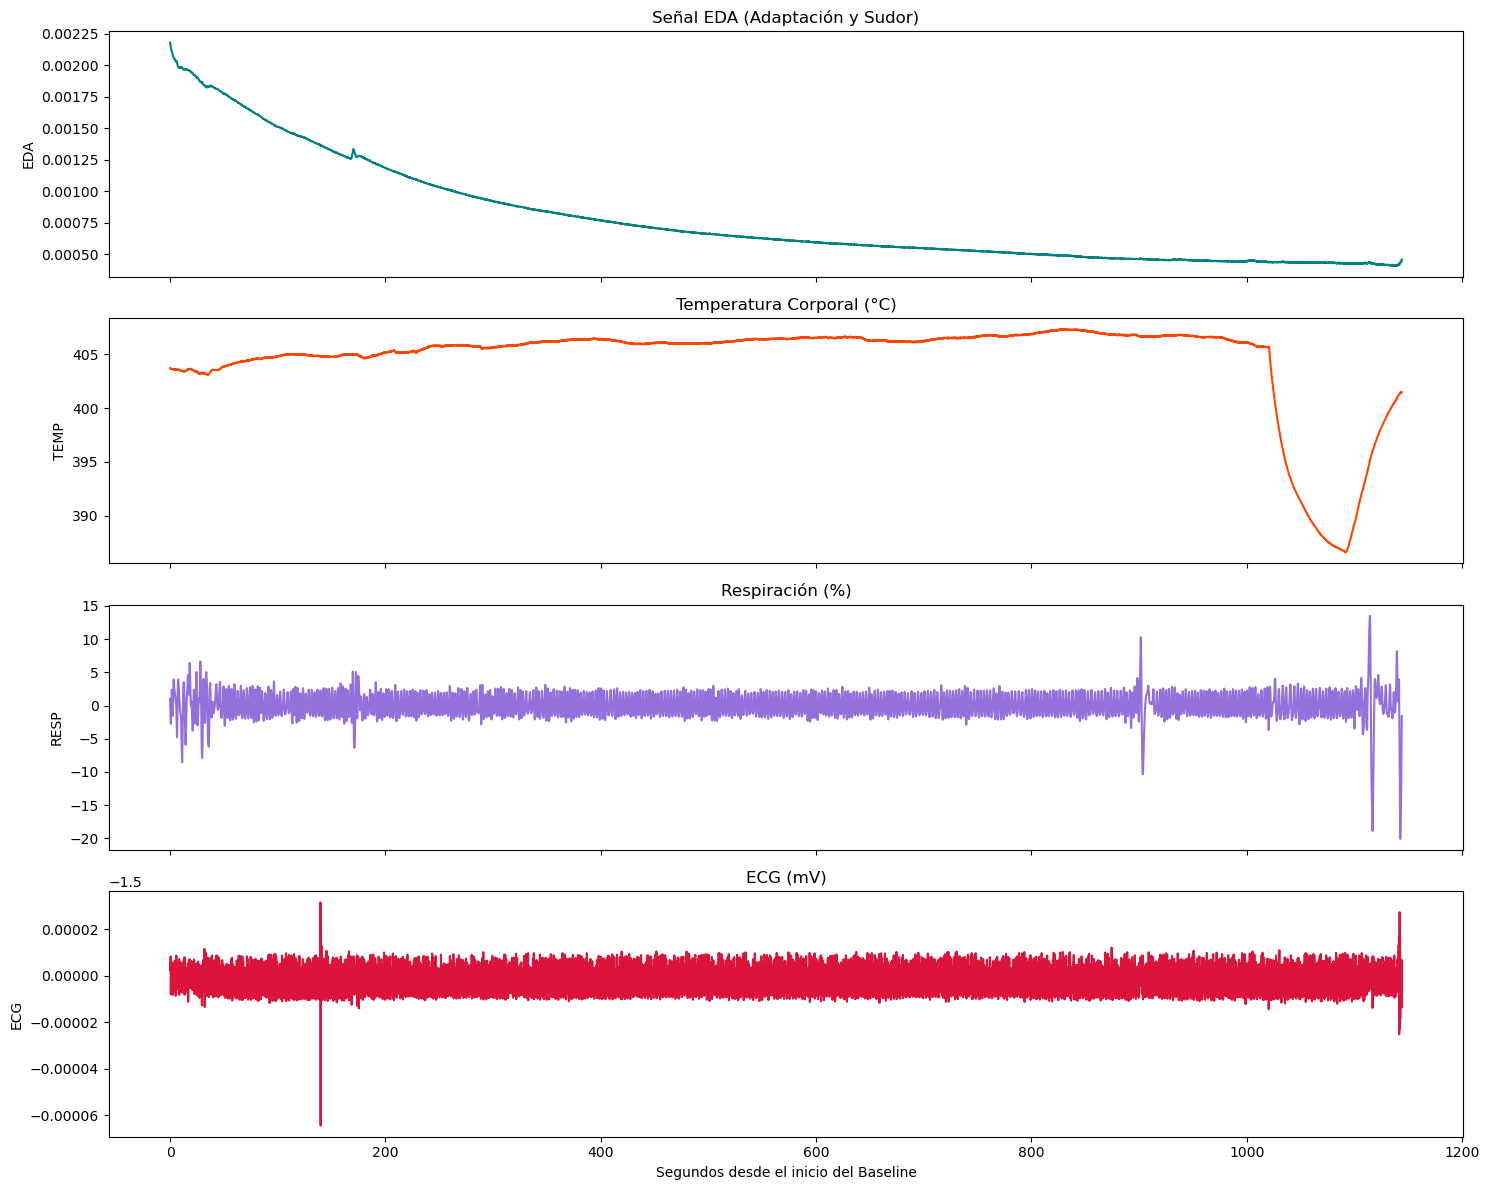

In [5]:
# Filtramos el baseline del dataframe ya re-muestreado (10Hz)
df_b = df_resampled[df_resampled['Label'] == 1].copy()
df_b['segundos'] = np.arange(len(df_b)) / 10

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

# 1. EDA - El indicador de sudor y adaptación
sns.lineplot(ax=axes[0], data=df_b, x='segundos', y='EDA', color='teal')
axes[0].set_title('Señal EDA (Adaptación y Sudor)')

# 2. TEMP - Para ver si hay deriva térmica al inicio
sns.lineplot(ax=axes[1], data=df_b, x='segundos', y='TEMP', color='orangered')
axes[1].set_title('Temperatura Corporal (°C)')

# 3. RESP - Para detectar si el sujeto respira agitado al principio
sns.lineplot(ax=axes[2], data=df_b, x='segundos', y='RESP', color='mediumpurple')
axes[2].set_title('Respiración (%)')

# 4. ECG - Para ver la actividad eléctrica del corazón
sns.lineplot(ax=axes[3], data=df_b, x='segundos', y='ECG', color='crimson')
axes[3].set_title('ECG (mV)')

plt.xlabel('Segundos desde el inicio del Baseline')
plt.tight_layout()
plt.show()

en esta grafica, vemos que todo es normal en el primero, despues en la temperatura, vemos que si sube un poco, al igual que en la respiracion , lo cual nos indica que estas variables si tienen una relacion con el nerviosisismo, en el caso de ECG, no hay mucha diferencia, asi que esta ultima no es tan relvante 

C:\Users\cuate\AppData\Local\Temp\ipykernel_41720\3805716730.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Baseline', 'Stress', 'Amusement', 'Meditation'])
C:\Users\cuate\AppData\Local\Temp\ipykernel_41720\3805716730.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Baseline', 'Stress', 'Amusement', 'Meditation'])


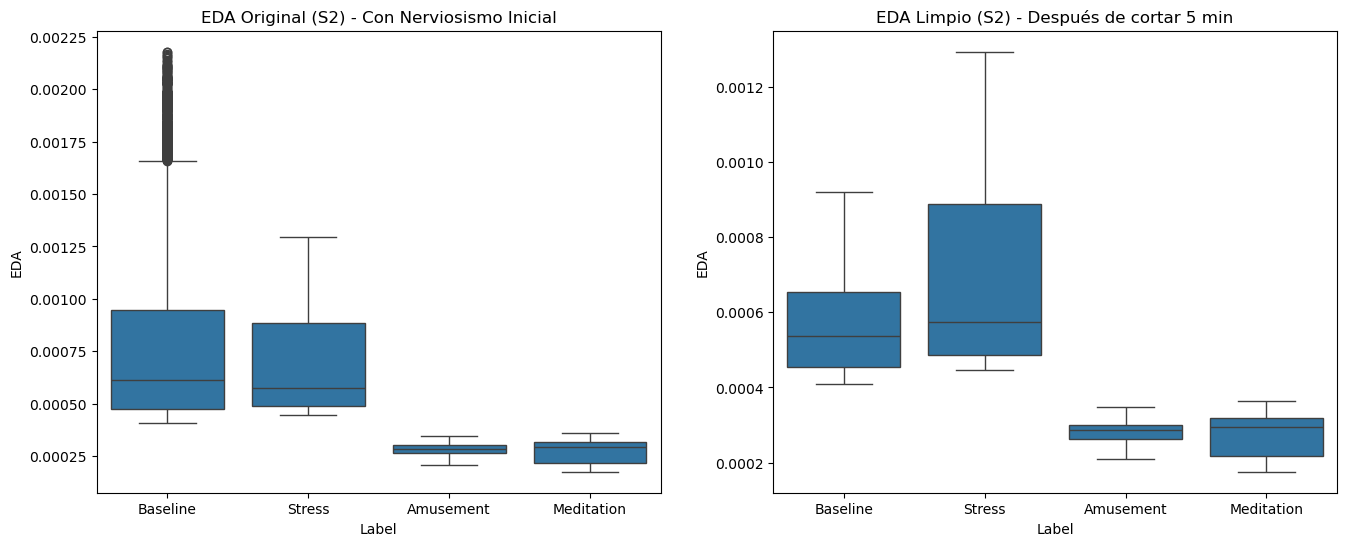

In [6]:
# 1. Definimos el tiempo de corte (en segundos)
segundos_a_cortar = 300 
muestras_a_cortar = segundos_a_cortar * 10 # 10Hz por el downsampling

# 2. Aplicamos el recorte específicamente al Baseline del sujeto S2
# Creamos una máscara para identificar qué filas son del Baseline
es_baseline = df_resampled['Label'] == 1

# Obtenemos los índices de las primeras 3000 muestras que sean Baseline
indices_recorte = df_resampled[es_baseline].index[:muestras_a_cortar]

# Creamos el nuevo DataFrame sin esas muestras iniciales
df_S2_limpio = df_resampled.drop(indices_recorte)

# 3. Visualización comparativa: 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot original 
sns.boxplot(ax=ax1, x='Label', y='EDA', data=df_resampled)
ax1.set_title("EDA Original (S2) - Con Nerviosismo Inicial")
ax1.set_xticklabels(['Baseline', 'Stress', 'Amusement', 'Meditation'])

# Boxplot después del corte
sns.boxplot(ax=ax2, x='Label', y='EDA', data=df_S2_limpio)
ax2.set_title("EDA Limpio (S2) - Después de cortar 5 min")
ax2.set_xticklabels(['Baseline', 'Stress', 'Amusement', 'Meditation'])

plt.show()

Aqui ya vemos que al corytar en 300 segundos, ya obtenemos lo que es algo mejor, pero por que 300 segundos es el numero ideal, esto es por que la serie tiene al rededor de 20 minutos, ademas de que la informacion proporcionada en el read me, nos dice que un sujeto tarda al rededor de 3 a 5 minutos en establizarse, por lo cual si tomamos en laxmimos que es 300 segundos, aun tenemos otros 15 minutos para analizar sin problema, tambien se puede ocupar la varianza en ventanas de tiempo, para comprobar este numero y no dejar nada al azar 

Ahora que tenemos a S2 limpio, sus datos siguen teniendo un problema: están en unidades reales (mV, µS), pero cada humano es diferente. Si mañana cargas al S3, quizás él suda el doble que el S2 por naturaleza.

Para que tu modelo de series de tiempo no se confunda, aplicaremos la Normalización Z-Score local
esto lo que hace es Transforma todos los datos para que tengan una media de 0 y una desviación de 1. Así, el modelo ya no mira si el EDA es "5" o "10", sino que mira cuánto se alejó el sujeto de su propio promedio.

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Creamos el objeto escalador
scaler = StandardScaler()

# 2. Seleccionamos las columnas de señales (sin incluir la Label)
columnas_senales = ['ECG', 'EDA', 'EMG', 'TEMP', 'RESP']

# 3. Aplicamos la normalización al DataFrame limpio de S2
df_S2_normalizado = df_S2_limpio.copy()
df_S2_normalizado[columnas_senales] = scaler.fit_transform(df_S2_limpio[columnas_senales])

# 4. Verificamos los resultados
print("Media después de normalizar (debe ser casi 0):")
print(df_S2_normalizado[columnas_senales].mean())
print("\nDesviación estándar (debe ser casi 1):")
print(df_S2_normalizado[columnas_senales].std())

# 5. Visualizamos el cambio en el DataFrame
df_S2_normalizado.head()

Media después de normalizar (debe ser casi 0):
ECG    -1.154434e-11
EDA    -1.756120e-16
EMG     2.195150e-17
TEMP    3.161017e-15
RESP    9.740980e-18
dtype: float64

Desviación estándar (debe ser casi 1):
ECG     1.000019
EDA     1.000019
EMG     1.000019
TEMP    1.000019
RESP    1.000019
dtype: float64


,ECG,EDA,EMG,TEMP,RESP,Label
6065,0.104072,1.998004,0.079065,1.387501,-0.229181,1.0
6066,0.270436,1.992740,-0.319484,1.385144,-0.370728,1.0
6067,1.474481,1.993301,-0.776403,1.386728,-0.468587,1.0
6068,-1.087128,1.992841,0.321960,1.385111,-0.531764,1.0
6069,-2.351259,1.993898,-0.429948,1.385700,-0.570703,1.0


hasta ahora, tenemos los datos ya limpioss, estuvimos trabajando con una muestra completa (los 700 hz), es decir, la conversion de formulas, el corte a 300 segundos 
del nerviosismo inicial, y el z score nos ayudaron a limpiar todo y prepararlo para empezar a trabajar con nuestro modelo, pero, si metemos los valores tal cual estan, son muy 
pesados, lo cual hara que se tarde mucho y sea un proceso mucho mas complicado, entonces lo que haremos es un Downsampling
El dataset WESAD registra las señales del pecho a 700 Hz. Esto significa que el dispositivo toma 700 medidas por segundo.Hacer downsampling consiste en reducir esa frecuencia (por ejemplo, a 10 Hz o 1 Hz). En lugar de tener 700 puntos en un segundo, tomamos el promedio de esos 700 puntos y los convertimos en un solo valor representativo por segundo.

¿Qué logramos al hacerlo? (Los 3 beneficios clave)
Aparte de lo que ya logramos con el Z-score y el corte de tiempo, el downsampling nos aporta:

1. Reducción de Ruido (Filtro Natural)
Las señales fisiológicas como el ECG o el EMG tienen mucho "ruido" eléctrico (pequeñas interferencias que no son latidos reales). Al promediar muchos puntos para crear uno solo, los picos de ruido se cancelan entre sí. Obtenemos una señal mucho más suave y limpia, lo que ayuda al modelo a ver la tendencia real del cuerpo y no el error del sensor.

2. Reducción masiva de "Peso" Computacional
Si dejas los datos a 700 Hz, una hora de grabación son 2,520,000 filas. Si los bajas a 10 Hz, esa misma hora son solo 36,000 filas.

Memoria RAM: Evitas que tu computadora o Google Colab se bloquee por falta de memoria.

Velocidad de entrenamiento: Tu modelo de IA se entrenará hasta 70 veces más rápido.

3. Ampliación de la "Ventana de Contexto" para la IA
Este es el punto más importante para tu modelo de series de tiempo. Las emociones no cambian en milisegundos; el estrés se desarrolla en segundos o minutos.

A 700 Hz: Para que una red neuronal (como una LSTM) "vea" 10 segundos de datos, tendría que procesar 7,000 pasos de tiempo. Es muy difícil que un modelo recuerde qué pasó al principio de esa cadena tan larga.

A 10 Hz: Para ver esos mismos 10 segundos, solo necesita procesar 100 pasos. Esto facilita enormemente que el modelo aprenda patrones a largo plazo.

In [8]:
# Como estamos a 700Hz y queremos 10Hz, agrupamos cada 70 muestras (700/70 = 10)
df_S2_final = df_S2_normalizado.groupby(np.arange(len(df_S2_normalizado)) // 70).mean()

# Verificamos el nuevo tamaño
print(f"Filas originales: {len(df_S2_normalizado)}")
print(f"Filas tras downsampling: {len(df_S2_final)}")

Filas originales: 25895
Filas tras downsampling: 370


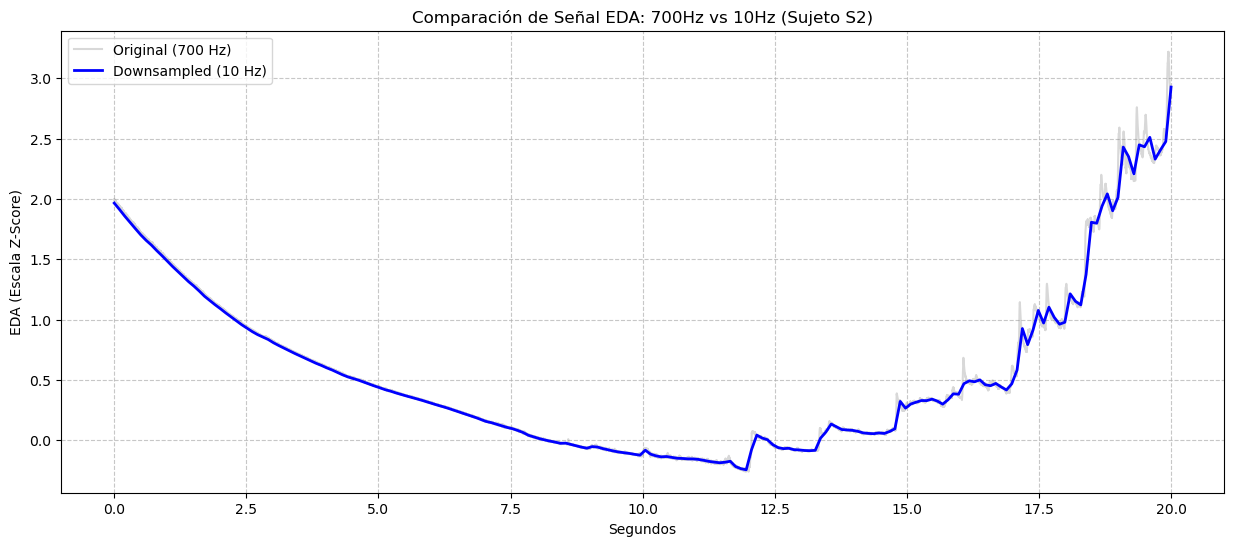

Valor máximo en 700Hz: 3.2197
Valor máximo en 10Hz: 2.9266


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraemos los fragmentos asegurándonos de que tengan datos
# Tomamos 20 segundos: a 700Hz son 14,000 datos, a 10Hz son 200 datos.
fragmento_700 = df_S2_normalizado['EDA'].iloc[0:14000].values
fragmento_10 = df_S2_final['EDA'].iloc[0:200].values

# 2. Creamos los ejes de tiempo (X) para que ambos duren lo mismo (20 seg)
tiempo_700 = np.linspace(0, 20, len(fragmento_700))
tiempo_10 = np.linspace(0, 20, len(fragmento_10))

plt.figure(figsize=(15, 6))

# Graficamos la señal original de fondo (gris)
plt.plot(tiempo_700, fragmento_700, alpha=0.3, label='Original (700 Hz)', color='gray')

# Graficamos la señal con Downsampling encima (azul)
plt.plot(tiempo_10, fragmento_10, label='Downsampled (10 Hz)', color='blue', linewidth=2)

plt.title("Comparación de Señal EDA: 700Hz vs 10Hz (Sujeto S2)")
plt.xlabel("Segundos")
plt.ylabel("EDA (Escala Z-Score)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Forzamos a que la gráfica se muestre
plt.show()

# Verificación rápida por consola
print(f"Valor máximo en 700Hz: {fragmento_700.max():.4f}")
print(f"Valor máximo en 10Hz: {fragmento_10.max():.4f}")

muy bien, ahora lo que haremos es aplicar todo esto que hemos hecho 
Transformar los datos con las formulas en el README
Cortar los 300 segundos del nerviosismo inicial
realizar la estandarizacion z score 
realizar el downsampling para reducir de 700hz a 10hz
Lo aplicaremos en todos los sujetos que tenemos y juntar todos los datos en un CSV para su procesamiento en el modelo posteriormente

In [10]:
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# 1. Configuración inicial
base_path = 'WESAD'  
sujetos = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

# Constantes para conversión (del README)
vcc = 3
chan_bit = 2**16

def convert_temp(signal):
    vout = (signal * vcc) / (chan_bit - 1)
    rntc = ((10**4) * vout) / (vcc - vout)
    temp_c = -273.15 + 1./(1.12764514e-03 + 2.34282709e-04 * np.log(rntc) + 8.77303013e-08 * (np.log(rntc)**3))
    return temp_c

# Lista para ir guardando los DataFrames de cada sujeto
lista_dfs = []

print("Iniciando procesamiento de sujetos...")

for s in sujetos:
    print(f"Procesando {s}...", end=" ")
    
    # A. Cargar archivo .pkl
    ruta = os.path.join(base_path, s, f'{s}.pkl')
    with open(ruta, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    fisiologicos = data['signal']['chest']
    labels = data['label']
    
    # B. Crear DataFrame y convertir unidades
    df_temp = pd.DataFrame({
        'ECG': (((fisiologicos['ECG'] / chan_bit) - 0.5) * vcc).flatten(),
        'EDA': (((fisiologicos['EDA'] / chan_bit) * vcc) / 0.12).flatten(),
        'EMG': fisiologicos['EMG'].flatten(),
        'TEMP': convert_temp(fisiologicos['Temp']).flatten(),
        'RESP': fisiologicos['Resp'].flatten(),
        'Label': labels
    })
    
    # C. Filtrar etiquetas válidas (1, 2, 3, 4)
    df_temp = df_temp[df_temp['Label'].isin([1, 2, 3, 4])]
    
    # D. Recorte de 300 segundos (nerviosismo inicial)
    # Solo cortamos el inicio del Baseline (Label 1) de este sujeto
    muestras_a_cortar = 300 * 700  # 300 seg * 700 Hz
    indices_baseline = df_temp[df_temp['Label'] == 1].index[:muestras_a_cortar]
    df_temp = df_temp.drop(indices_baseline)
    
    # E. Normalización Z-Score (POR SUJETO)
    cols = ['ECG', 'EDA', 'EMG', 'TEMP', 'RESP']
    scaler = StandardScaler()
    df_temp[cols] = scaler.fit_transform(df_temp[cols])
    
    # F. Downsampling (de 700Hz a 10Hz)
    df_resampled = df_temp.groupby(np.arange(len(df_temp)) // 70).mean()
    
    # G. ¡IMPORTANTE! Añadir ID del sujeto para no perder el rastro
    df_resampled['Subject_ID'] = s
    
    lista_dfs.append(df_resampled)
    print("¡Hecho!")

# 2. Unir todos los sujetos en un solo DataFrame gigante
df_final = pd.concat(lista_dfs, ignore_index=True)

print(f"\nProcesamiento completado.")
print(f"Dimensiones finales del dataset: {df_final.shape}")
# Ver balance de clases total
print(df_final['Label'].value_counts())

# Guardar el resultado para no tener que repetir el proceso
df_final.to_csv('WESAD_limpio_10Hz.csv', index=False)

Iniciando procesamiento de sujetos...
Procesando S2... ¡Hecho!
Procesando S3... 

C:\Users\cuate\AppData\Local\Temp\ipykernel_41720\904915305.py:18: RuntimeWarning: invalid value encountered in log
  temp_c = -273.15 + 1./(1.12764514e-03 + 2.34282709e-04 * np.log(rntc) + 8.77303013e-08 * (np.log(rntc)**3))


¡Hecho!
Procesando S4... ¡Hecho!
Procesando S5... ¡Hecho!
Procesando S6... ¡Hecho!
Procesando S7... ¡Hecho!
Procesando S8... ¡Hecho!
Procesando S9... ¡Hecho!
Procesando S10... ¡Hecho!
Procesando S11... ¡Hecho!
Procesando S13... ¡Hecho!
Procesando S14... ¡Hecho!
Procesando S15... ¡Hecho!
Procesando S16... ¡Hecho!
Procesando S17... ¡Hecho!

Procesamiento completado.
Dimensiones finales del dataset: (404585, 7)
Label
1.000000    131110
4.000000    118055
2.000000     99657
3.000000     55745
3.985714         6
3.971429         4
3.014286         3
2.028571         3
2.971429         2
Name: count, dtype: int64


In [ ]:
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# 1. Configuración
base_path = 'WESAD' # Ajusta tu ruta
sujetos = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

def convert_temp(signal):
    vcc = 3
    chan_bit = 2**16
    vout = (signal * vcc) / (chan_bit - 1)
    # Evitamos valores que rompan el logaritmo
    rntc = ((10**4) * vout) / np.clip((vcc - vout), 1e-9, None)
    rntc = np.clip(rntc, 1e-9, None)
    temp_c = -273.15 + 1./(1.12764514e-03 + 2.34282709e-04 * np.log(rntc) + 8.77303013e-08 * (np.log(rntc)**3))
    return temp_c

lista_dfs = []

print(" Iniciando procesamiento maestro...")

for s in sujetos:
    print(f" Procesando {s}...", end=" ")
    
    ruta = os.path.join(base_path, s, f'{s}.pkl')
    with open(ruta, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    fisiologicos = data['signal']['chest']
    
    # Crear DataFrame inicial
    df_s = pd.DataFrame({
        'ECG': (((fisiologicos['ECG'] / 2**16) - 0.5) * 3).flatten(),
        'EDA': (((fisiologicos['EDA'] / 2**16) * 3) / 0.12).flatten(),
        'EMG': fisiologicos['EMG'].flatten(),
        'TEMP': convert_temp(fisiologicos['Temp']).flatten(),
        'RESP': fisiologicos['Resp'].flatten(),
        'Label': data['label']
    })
    
    # 1. Filtrar solo etiquetas de interés (1:Base, 2:Stress, 3:Amusement, 4:Meditation)
    df_s = df_s[df_s['Label'].isin([1, 2, 3, 4])].copy()
    
    # 2. Recorte de 300s (nerviosismo inicial) solo en el Baseline
    muestras_corte = 300 * 700
    indices_b = df_s[df_s['Label'] == 1].index[:muestras_corte]
    df_s = df_s.drop(indices_b)
    
    # 3. Normalización Z-Score (Individual por sujeto)
    cols = ['ECG', 'EDA', 'EMG', 'TEMP', 'RESP']
    df_s[cols] = StandardScaler().fit_transform(df_s[cols])
    
    # 4. Downsampling (700Hz -> 10Hz) 
    # Promedio para señales, Moda para la etiqueta
    grupos = np.arange(len(df_s)) // 70
    
    # Agregamos por media las señales y por el primer valor la etiqueta (asumiendo estabilidad)
    df_res = df_s.groupby(grupos).agg({
        'ECG': 'mean',
        'EDA': 'mean',
        'EMG': 'mean',
        'TEMP': 'mean',
        'RESP': 'mean',
        'Label': lambda x: x.value_counts().index[0] # Toma la etiqueta más frecuente en la ventana
    })
    
    df_res['Subject_ID'] = s
    lista_dfs.append(df_res)

# Unir todo
df_final = pd.concat(lista_dfs, ignore_index=True)

# Limpieza final de seguridad
df_final = df_final.dropna()
df_final['Label'] = df_final['Label'].astype(int)

print("\n ¡Dataset final listo!")
print(f"Forma del dataframe: {df_final.shape}")
print(df_final['Label'].value_counts())
df_final.to_parquet('WESAD_10Hz_Limpio.parquet')

 Iniciando procesamiento maestro...
 Procesando S2...  Procesando S3...  Procesando S4...  Procesando S5...  Procesando S6...  Procesando S7...  Procesando S8...  Procesando S9...  Procesando S10...  Procesando S11...  Procesando S13...  Procesando S14...  Procesando S15...  Procesando S16...  Procesando S17... 
✨ ¡Dataset final listo!
Forma del dataframe: (404585, 7)
Label
1    131110
4    118065
2     99660
3     55750
Name: count, dtype: int64
